In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Libraries and imports:

In [ ]:
import os
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
import torchvision.models as models
import wandb
from sklearn.metrics import accuracy_score, f1_score
from transformers import ASTForAudioClassification

# Wandb Login:

In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")
os.environ["WANDB_API_KEY"] = secret_value_0

In [4]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

# EDA:

Sample rate: 44100
Duration (sec): 30.013333333333332


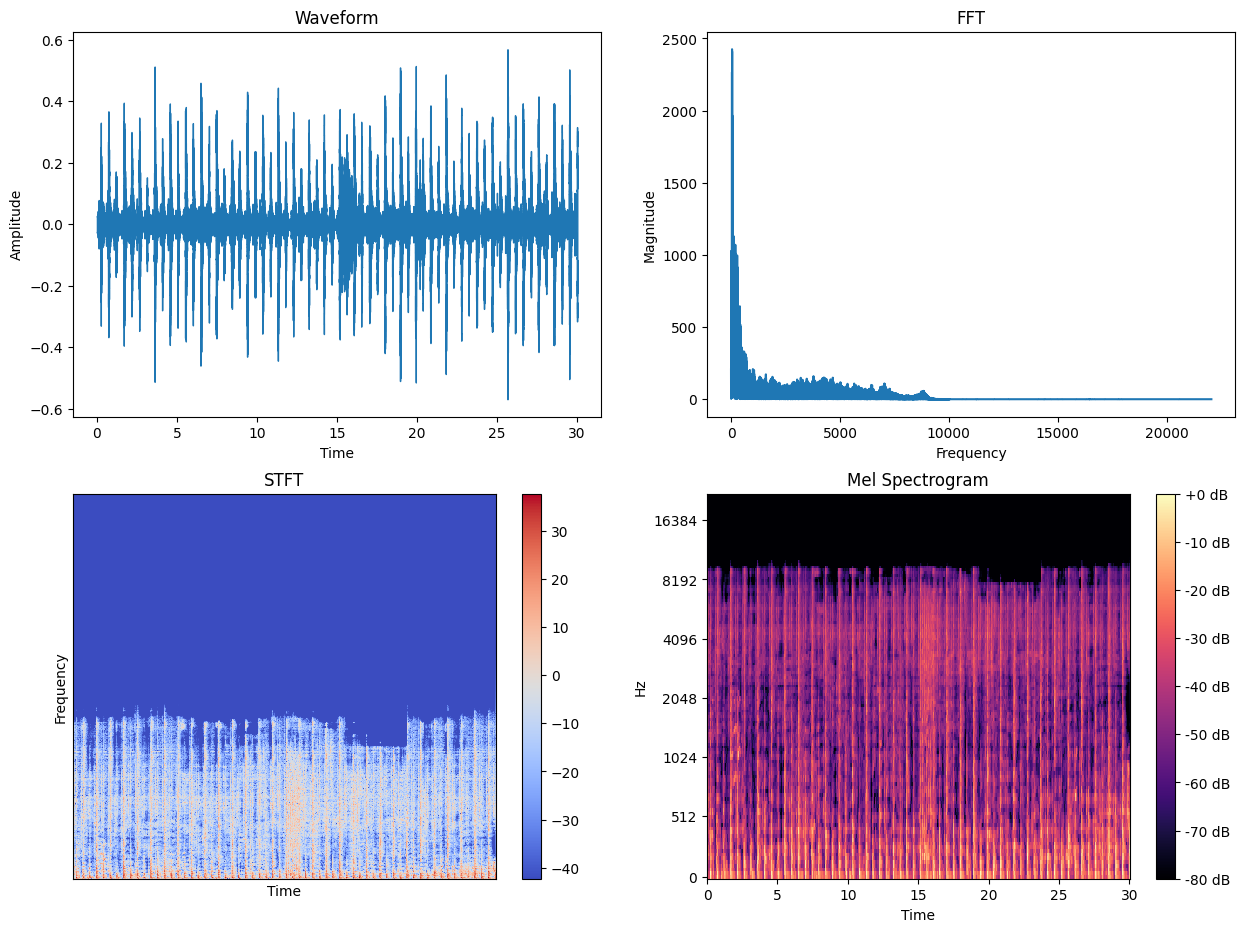

In [9]:
# Train data

import librosa.display

example_file = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00000/drums.wav"

y, sr = librosa.load(example_file, sr=None)
print("Sample rate:", sr)
print("Duration (sec):", len(y)/sr)

plt.figure(figsize=(15,11))

plt.subplot(2,2,1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.subplot(2,2,2)
fft = np.fft.fft(y)
magnitude = np.abs(fft)
frequency = np.linspace(0, sr, len(magnitude))
left_frequency = frequency[:int(len(frequency)/2)]
left_magnitude = magnitude[:int(len(magnitude)/2)]
plt.plot(left_frequency, left_magnitude)
plt.title("FFT")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")

plt.subplot(2,2,3)
stft = librosa.core.stft(y, hop_length=512, n_fft=2048)
spectogram = np.abs(stft)
log_spectogram = librosa.amplitude_to_db(spectogram)
librosa.display.specshow(log_spectogram, sr=sr, hop_length=512)
plt.title("STFT")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()

plt.subplot(2,2,4)
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")

plt.show()

Mashup sample rate: 22050
Mashup duration: 30.00018140589569


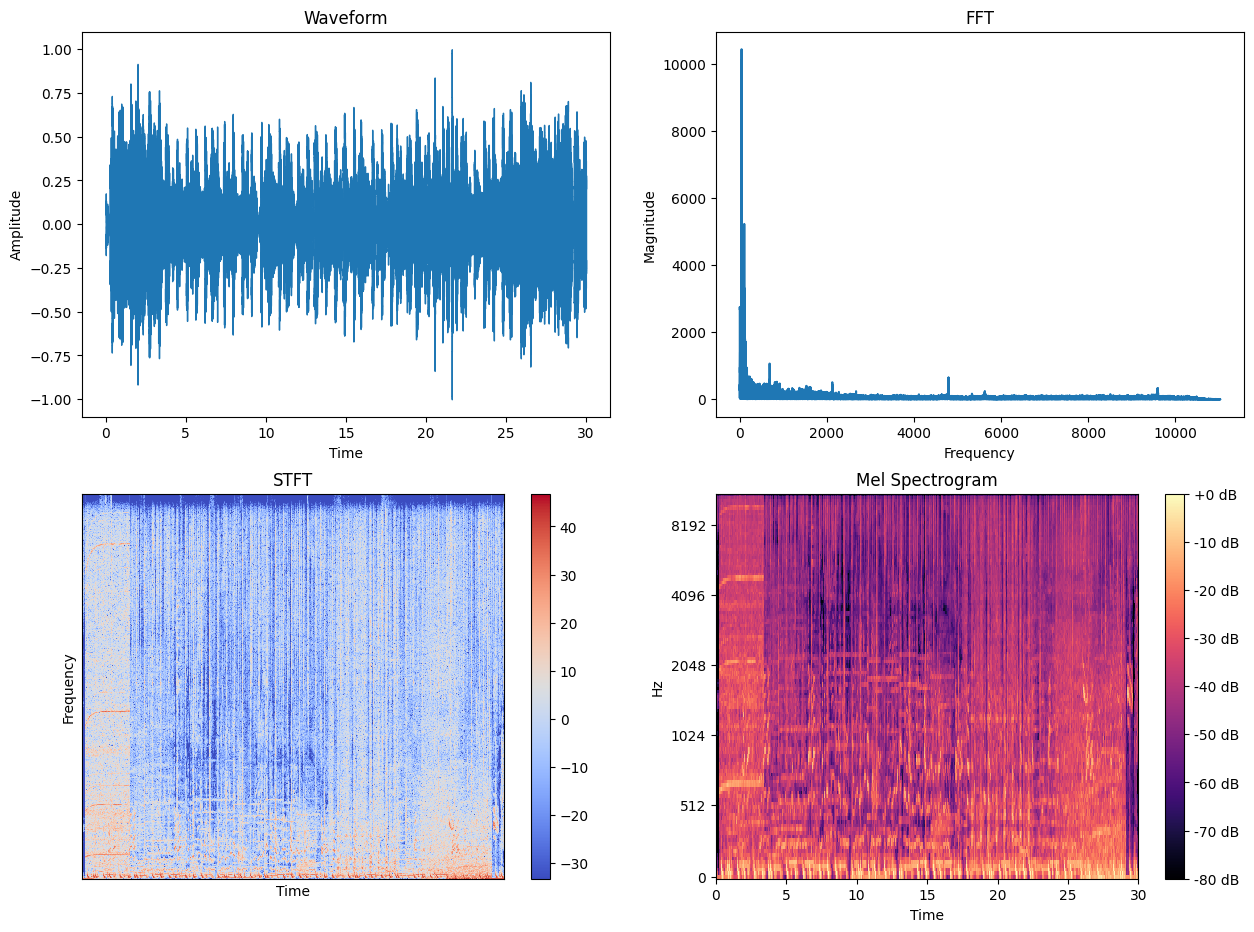

In [10]:
# Test data

test_eg = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups/song0001.wav"
y, sr = librosa.load(test_eg, sr=None)
print("Mashup sample rate:", sr)
print("Mashup duration:", len(y)/sr)

plt.figure(figsize=(15,11))

plt.subplot(2,2,1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.subplot(2,2,2)
fft = np.fft.fft(y)
magnitude = np.abs(fft)
frequency = np.linspace(0, sr, len(magnitude))
left_frequency = frequency[:int(len(frequency)/2)]
left_magnitude = magnitude[:int(len(magnitude)/2)]
plt.plot(left_frequency, left_magnitude)
plt.title("FFT")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")

plt.subplot(2,2,3)
stft = librosa.core.stft(y, hop_length=512, n_fft=2048)
spectogram = np.abs(stft)
log_spectogram = librosa.amplitude_to_db(spectogram)
librosa.display.specshow(log_spectogram, sr=sr, hop_length=512)
plt.title("STFT")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()

plt.subplot(2,2,4)
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")

plt.show()

In [7]:
# DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
# GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
# STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

# train_srs = []
# train_durations = []
# train_silence = []
# train_rms = []

# for genre in tqdm(GENRES): # looping through each genre

#     # storing the path of each genre
#     genre_path = os.path.join(DATA_PATH, genre)
 
#     for song in os.listdir(genre_path): # looping through all songs in a particular genre

#         # storing the path of each song
#         song_path = os.path.join(genre_path, song)

#         for stem in STEMS: # looping through all stems of a particular song of a particular genre

#             # storing the path of each stem
#             audio_path = os.path.join(song_path, stem)

#             y, sr = librosa.load(audio_path, sr=None)
#             duration = len(y) / sr
#             silence_ratio = np.mean(np.abs(y) < 1e-4)
#             rms = np.mean(librosa.feature.rms(y=y))
            
#             train_srs.append(sr)
#             train_durations.append(duration)
#             train_silence.append(silence_ratio)
#             train_rms.append(rms)

# print("Train unique SRs:", set(train_srs))
# print("Train duration mean:", np.mean(train_durations))
# print("Train duration std:", np.std(train_durations))
# print("Train silence mean:", np.mean(train_silence))
# print("Train RMS mean:", np.mean(train_rms))

# Train unique SRs: {44100}
# Train duration mean: 30.02404707482993
# Train duration std: 0.08087336094347475
# Train silence mean: 0.16854941092207973
# Train RMS mean: 0.04491053

* All audio files in the dataset have the same sampling rate: 44.1 kHz.
* Mean duration of all audio files is 30 seconds with very little variation.
* About 16.8% of samples are near zero amplitude.
* Average loudness ≈ 0.045

In [8]:
# mashup_path = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups"

# test_srs = []
# test_durations = []
# test_silence = []
# test_rms = []

# for song in tqdm(os.listdir(mashup_path)): # loopig through all the mashup files
#     audio_path = os.path.join(mashup_path, song) # storing the path of the mashup file

#     y, sr = librosa.load(audio_path, sr=None) # loading the file
    
#     duration = len(y) / sr
#     silence_ratio = np.mean(np.abs(y) < 1e-4)
#     rms = np.mean(librosa.feature.rms(y=y))
    
#     test_srs.append(sr)
#     test_durations.append(duration)
#     test_silence.append(silence_ratio)
#     test_rms.append(rms)

# print("Test unique SRs:", set(test_srs))
# print("Test duration mean:", np.mean(test_durations))
# print("Test duration std:", np.std(test_durations))
# print("Test silence mean:", np.mean(test_silence))
# print("Test RMS mean:", np.mean(test_rms))

# Test unique SRs: {22050}
# Test duration mean: 28.653239927317504
# Test duration std: 3.772994605159907
# Test silence mean: 0.0009087508105784579
# Test RMS mean: 0.12791249

* All audio files in the dataset have the same sampling rate: 22.05 kHz.
* Mean duration of all audio files is 28.6 seconds with a little variation.
* Test audio contains almost no silent samples.
* Average loudness ≈ 0.128

### Summary of Differences Between Training and Test Sets

1. Sampling Rate:<br>
The training audio files have a sampling rate of 44,100 Hz, whereas the test audio files use 22,050 Hz. This difference may lead to variations in spectral representations, thus, I decided to downsample during preprocessing.

2. Audio Duration:<br>
Training clips are highly consistent with an average duration of 30 seconds and very low variance, while test clips show greater variability with a mean duration of 28.65 seconds and a larger standard deviation, thus, I decided to randomly crop 5 sec for training and use 5 sec sliding window for inference/testing.

3. Silence Proportion:<br>
The training set contains a higher proportion of near-silent samples (16.8%), indicating the presence of pauses or low-energy segments, this could be beacuse we are loading individual stems rather than a song, thus, there are many instances where the stem pauses and is not continuous. However, the test set is a complete song containing all the stems with added noise, thus, it has almost no silent samples (0.09%), suggesting more continuous audio activity. Therefore, I decided to mix stems from different songs of the same genre during preprocessing.

4. Signal Energy (RMS):<br>
The average RMS energy in the test set (0.128) is significantly higher than in the training set (0.045), indicating that the test audio signals are louder or more compressed, thus, I decided to normalize the waveforms during preprocessing.

# Train-Validation Split:

**For each genre:**
* 100 songs split into:
  * 80 songs → train set
  * 20 songs → validation set

***Splitting the data before pre-processing in order to avoid data leakage because mixing stems from different songs is going to be one of the pre-processing step.***

In [9]:
GENRES_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
genres = sorted(os.listdir(GENRES_PATH))
random.seed(42)

train_songs = {}
val_songs = {}

for genre in genres: # looping through all the genres
    genre_path = os.path.join(GENRES_PATH, genre) # storing the path of each genre
    songs = os.listdir(genre_path) # storing the list of all the 100 songs for each genre

    random.shuffle(songs) # randomly shuffling the list containing the songs

    # diving the songs with 80-20 split with 80% of the songs for train and 20% of the songs for validation set
    train_songs[genre] = songs[:int(0.8*len(songs))] 
    val_songs[genre] = songs[int(0.8*len(songs)):]

print("Example:")
print("Genre name:", genres[0], "\nTrain:", len(train_songs[genres[0]]), 
      "\nVal:", len(val_songs[genres[0]]), "\nTrain songs:", train_songs[genres[0]])

Example:
Genre name: blues 
Train: 80 
Val: 20 
Train songs: ['blues.00058', 'blues.00029', 'blues.00014', 'blues.00008', 'blues.00009', 'blues.00000', 'blues.00006', 'blues.00091', 'blues.00099', 'blues.00059', 'blues.00052', 'blues.00012', 'blues.00072', 'blues.00026', 'blues.00055', 'blues.00093', 'blues.00036', 'blues.00096', 'blues.00015', 'blues.00078', 'blues.00010', 'blues.00011', 'blues.00027', 'blues.00085', 'blues.00094', 'blues.00049', 'blues.00069', 'blues.00030', 'blues.00003', 'blues.00050', 'blues.00016', 'blues.00020', 'blues.00022', 'blues.00076', 'blues.00089', 'blues.00048', 'blues.00064', 'blues.00034', 'blues.00018', 'blues.00092', 'blues.00033', 'blues.00053', 'blues.00037', 'blues.00082', 'blues.00041', 'blues.00031', 'blues.00075', 'blues.00083', 'blues.00024', 'blues.00013', 'blues.00066', 'blues.00038', 'blues.00056', 'blues.00086', 'blues.00001', 'blues.00044', 'blues.00079', 'blues.00043', 'blues.00084', 'blues.00005', 'blues.00004', 'blues.00074', 'blues.0

# Creating Dataset:

## Noise file:

Creating a list which contains the paths of all the noise files.

In [10]:
ESC_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio"

noise_files = []

for file in os.listdir(ESC_PATH): # looping through the list of noise files
    
    if file.endswith(".wav"): # making sure it is a noise file by checking whether it ends with ".wav"
        
        # taking the path of the noise file and appending it to the list
        noise_files.append(os.path.join(ESC_PATH, file))

print("Total noise files:", len(noise_files))

Total noise files: 2000


## Pre-processing:

**Pre-processing Pipeline:**

For each training sample:
1. Randomly selecting:
   * drums from Song A
   * bass from Song B
   * vocals from Song C
   * others from Song D<br>
   (same genre, train split only)
2. Downsampling to 16,000 Hz to deal with sampling rate mismatch
3. Randomly gaining/scaling per stem to induce stem level variations in order to increase robustness
4. Mixing stems
5. Randomly cropping 5 sec instead of training on the whole duration to decrease training time and add diversity
6. With probability p=0.3 → adding a random noise file
7. Normalizing to deal with loudness bias
8. Log-melspectogram

***The goal is to simulate test conditions as much as possible.***

In [11]:
# taking the path of the audio file and sample rate and returning the waveform
def load_audio(path, sr): 
    y, _ = librosa.load(path, sr=sr)
    return y


# taking the waveform and randomly cropping to the number of samples required
def random_crop(y, samples_required):
    # if the length of the waveform is less than the number of samples required then padding it with zeroes
    if len(y) <= samples_required:
        num_padding = samples_required - len(y)
        y = np.pad(y, (0, num_padding))
        return y

    # randomly taking the starting point or the index from where the cropping will be done
    starting_point = random.randint(0, len(y) - samples_required)
    # cropping the waveform
    y = y[starting_point : starting_point + samples_required]
    
    # returning the cropped waveform
    return y
    

# taking the waveform and cropping it from the center to the number of samples required
def center_crop(y, samples_required):
    # if the length of the waveform is less than the number of samples required then padding it with zeroes
    if len(y) <= samples_required:
        num_padding = samples_required - len(y)
        y = np.pad(y, (0, num_padding))
        return y

    # taking the starting point/index from the center
    starting_point = (len(y) - samples_required)//2
    # cropping the waveform
    y = y[starting_point : starting_point + samples_required]

    # returning the cropped waveform
    return y
    
    
# choosing a noise file at random and adding it to the waveform
def add_noise(y, noise_files, sr, samples_required):
    noise_path = random.choice(noise_files) # storing the path of a random noise file
    noise = load_audio(noise_path, sr) # loading the noise file
    noise = random_crop(noise, samples_required) # randomly cropping
    
    # Normalizing (different noises can have different loudness levels)
    noise = noise / (np.max(np.abs(noise)) + 1e-6) # adding 1e-6 to prevent division by zero error
    # Scaling the noise down so it won't overpower the music
    noise = noise * random.uniform(0.05, 0.2)

    # adding the noise to the audio and returning it
    return y + noise
    

# main pre-processing function
def preprocess(bass_path, drums_path, other_path, vocals_path, noise_files, sr=16000, duration=5, n_fft=1024, hop_length=160, n_mels=128, train=True):
    samples_needed = sr * duration

    # loading the path of each stem
    bass = load_audio(bass_path, sr=sr)
    drums = load_audio(drums_path, sr=sr)
    other = load_audio(other_path, sr=sr)
    vocals = load_audio(vocals_path, sr=sr)

    if train:
        # randomly gaining/scaling for robustness
        bass *= random.uniform(0.6, 1.4)
        drums *= random.uniform(0.6, 1.4)
        other *= random.uniform(0.6, 1.4)
        vocals *= random.uniform(0.6, 1.4)

    # mixing the stems according to the minimum length of the stem
    min_length = min(len(bass), len(drums), len(other), len(vocals))
    mixed = (
        bass[:min_length] +
        drums[:min_length] +
        other[:min_length] +
        vocals[:min_length]
    )

    if train:
        mixed = random_crop(mixed, samples_needed) # randomly cropping the mixed audio      
        if random.random() < 0.3: # with 30% probability - adding a radom noise file to the mixed audio
            mixed = add_noise(mixed, noise_files, sr, samples_needed)
    else: 
        mixed = center_crop(mixed, samples_needed) # center cropping for validation

    # Normalizing to prevent loudness bias
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-6) # adding 1e-6 to prevent division by zero error

    # computing melspectogram
    mel = librosa.feature.melspectrogram(
        y=mixed,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )

    # converting to db
    log_mel = librosa.power_to_db(mel, ref=np.max)

    # returning the melspectogram with an added dimension -> (1, n_mels=128, time frames=501)
    return torch.tensor(log_mel).unsqueeze(0).float()

## Train and Validation set:

* Creating pre-processed train and validation dataset
* Saving the pre-processed data as ".pt" file
* Creating train and validation dataframe alongside the dataset which contains the path of each .pt file, genre and label for every row/sample
* Train data → 30,000 samples (3,000 per genre)
* Validation data → 7,500 (750 per genre)

***Creating a new dataset by pre-processing and saving it as .pt file in orer to decrease training time.***

In [12]:
# GENRES_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
# genres = sorted(os.listdir(GENRES_PATH))

# random.seed(42)

# train_paths = []
# train_labels = []
# train_genres = []
# TRAIN_PER_GENRE = 3000

# for genre_id, genre in enumerate(genres): # looping through all the genres
      
#     # getting the list of all the songs belonging to that particular genre
#     train_song_list = train_songs[genre] 

#     # creating a directory
#     train_dir = f"processed_dataset/train/{genre_id}"
#     os.makedirs(train_dir, exist_ok=True)

#     # looping 3000 times per genre
#     for i in tqdm(range(TRAIN_PER_GENRE), desc=f"Train {genre}"):

#         # picking 4 songs at random
#         song1, song2, song3, song4 = random.sample(train_song_list, 4)

#         # storing the path of different stem for each song
#         bass_path = os.path.join(GENRES_PATH, genre, song1, "bass.wav")
#         drums_path = os.path.join(GENRES_PATH, genre, song2, "drums.wav")
#         other_path = os.path.join(GENRES_PATH, genre, song3, "other.wav")
#         vocals_path = os.path.join(GENRES_PATH, genre, song4, "vocals.wav")

#         # passing the stored stem paths into pre-processing function and getting tensors in return
#         tensor = preprocess(
#             bass_path,
#             drums_path,
#             other_path,
#             vocals_path,
#             noise_files=noise_files,
#             train=True
#         )

#         # creating a path and storing the tensor at that path
#         save_path = os.path.abspath(os.path.join(train_dir, f"{genre_id}_{i}.pt"))
#         torch.save(tensor, save_path)

#         # storing the path of the tensor, label and genre in their respective list which is going to be used to create a dataframe
#         train_paths.append(save_path)
#         train_labels.append(genre_id)
#         train_genres.append(genre)


# val_paths = []
# val_labels = []
# val_genres = []
# VAL_PER_GENRE = 750

# for genre_id, genre in enumerate(genres): # looping through all the genres

#     # getting the list of all the songs belonging to that particular genre
#     val_song_list = val_songs[genre]

#     # creating a directory
#     val_dir = f"processed_dataset/val/{genre_id}"
#     os.makedirs(val_dir, exist_ok=True)

#     # looping 750 times per genre
#     for i in tqdm(range(VAL_PER_GENRE), desc=f"Val {genre}"):

#         # picking 4 songs at random
#         song1, song2, song3, song4 = random.sample(val_song_list, 4)

#         # storing the path of different stem for each song
#         bass_path = os.path.join(GENRES_PATH, genre, song1, "bass.wav")
#         drums_path = os.path.join(GENRES_PATH, genre, song2, "drums.wav")
#         other_path = os.path.join(GENRES_PATH, genre, song3, "other.wav")
#         vocals_path = os.path.join(GENRES_PATH, genre, song4, "vocals.wav")

#         # passing the stored stem paths into pre-processing function and getting tensors in return
#         tensor = preprocess(
#             bass_path,
#             drums_path,
#             other_path,
#             vocals_path,
#             noise_files=noise_files,
#             train=False
#         )

#         # creating a path and storing the tensor at that path
#         save_path = os.path.abspath(os.path.join(val_dir, f"{genre_id}_{i}.pt"))
#         torch.save(tensor, save_path)

#         # storing the path of the tensor, label and genre in their respective list which is going to be used to create a dataframe
#         val_paths.append(save_path)
#         val_labels.append(genre_id)
#         val_genres.append(genre)
        

# # creating a directory to store the dataframe as .csv file
# os.makedirs("metadata", exist_ok=True)

# # creating train and val dataframe
# df_train = pd.DataFrame({
#     "path": train_paths,
#     "genre": train_genres,
#     "label": train_labels,
# })
# df_val = pd.DataFrame({
#     "path": val_paths,
#     "genre": val_genres,
#     "label": val_labels,
# })

# # saving it as .csv file
# df_train.to_csv("metadata/train_metadata.csv", index=False)
# df_val.to_csv("metadata/val_metadata.csv", index=False)

In [13]:
# loading the train and val csv files
df_train = pd.read_csv("/kaggle/input/datasets/sahilalam75/messy-mashup-preprocessed/metadata/train_metadata.csv")
df_val = pd.read_csv("/kaggle/input/datasets/sahilalam75/messy-mashup-preprocessed/metadata/val_metadata.csv")

# removing "/kaggle/working/" from the path
df_train["path"] = df_train["path"].str.replace("/kaggle/working/", "", regex=False)
df_val["path"] = df_val["path"].str.replace("/kaggle/working/", "", regex=False)

print("Train data:")
display(df_train.head())
print(df_train.shape)
print("\n\nVal data:")
display(df_val.head())
print(df_val.shape)

Train data:


,path,genre,label
0,processed_dataset/train/0/0_0.pt,blues,0
1,processed_dataset/train/0/0_1.pt,blues,0
2,processed_dataset/train/0/0_2.pt,blues,0
3,processed_dataset/train/0/0_3.pt,blues,0
4,processed_dataset/train/0/0_4.pt,blues,0


(30000, 3)


Val data:


,path,genre,label
0,processed_dataset/val/0/0_0.pt,blues,0
1,processed_dataset/val/0/0_1.pt,blues,0
2,processed_dataset/val/0/0_2.pt,blues,0
3,processed_dataset/val/0/0_3.pt,blues,0
4,processed_dataset/val/0/0_4.pt,blues,0


(7500, 3)


## Test set:

In [14]:
df_test = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv")
display(df_test.head())
df_test.shape

,id,filename
0,1,mashups/song0001.wav
1,2,mashups/song0002.wav
2,3,mashups/song0003.wav
3,4,mashups/song0004.wav
4,5,mashups/song0005.wav


(3020, 2)

**Pre-processing mashup files:**
*  Loading each mashup file by downsampling to 16,000 Hz to deal with sampling rate mismatch
* Saving the waveform as ".pt" file in order to create test dataset
* Creating a dataframe alongside dataset which will contain the id and the path of the .pt file for each mashup file

*I decided to store waveforms instead of melspectograms because the inference is going to be done using a 5 sec sliding window / dividing the audio into multiple segments of 5 sec each, then averaging their probabilities, thus, melspectogram will be computed during inference.*

In [15]:
# TEST_DIR = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
# test_paths = []
# test_ids = []

# # creating directory
# os.makedirs("processed_dataset/test_waveforms", exist_ok=True)

# # looping through each row in test.csv
# for _, row in tqdm(df_test.iterrows(), total=len(df_test)):

#     # storing the path of mashup file
#     audio_path = os.path.join(TEST_DIR, row["filename"])

#     # loading the mashup file
#     y, _ = librosa.load(audio_path, sr=16000)

#     # converting to tensor
#     tensor = torch.tensor(y).float()

#     # creating the path and saving the tensor to the path
#     save_path = os.path.abspath(f"processed_dataset/test_waveforms/{row['id']}.pt")
#     torch.save(tensor, save_path)

#     # storing the path and the id in their respective list which is going to be used to create a dataframe
#     test_paths.append(save_path)
#     test_ids.append(row["id"])

# # creating a directory to store the dataframe as .csv file
# os.makedirs("metadata", exist_ok=True)

# # creating test dataframe
# df_test = pd.DataFrame({
#     "id": test_ids,
#     "path": test_paths
# })

# # saving the dataframe as .csv file
# df_test.to_csv("metadata/test_metadata.csv", index=False)

In [16]:
# loading the test csv file
df_test = pd.read_csv("/kaggle/input/datasets/sahilalam75/messy-mashup-preprocessed/metadata/test_metadata.csv")

# removing "/kaggle/working/" from the path
df_test["path"] = df_test["path"].str.replace("/kaggle/working/", "", regex=False)

display(df_test.head())
print(df_test.shape)

,id,path
0,1,processed_dataset/test_waveforms/1.pt
1,2,processed_dataset/test_waveforms/2.pt
2,3,processed_dataset/test_waveforms/3.pt
3,4,processed_dataset/test_waveforms/4.pt
4,5,processed_dataset/test_waveforms/5.pt


(3020, 2)


# Dataset and DataLoader:

## Train and Validation Dataset:

In [17]:
class Train_Val_Dataset(Dataset):
    def __init__(self, df, 
                 root_dir="/kaggle/input/datasets/sahilalam75/messy-mashup-preprocessed", 
                 train=True,
                 time_mask = T.TimeMasking(time_mask_param=30),
                 frequency_mask = T.FrequencyMasking(freq_mask_param=15)):
        
        self.df = df
        self.root_dir = root_dir
        self.train = train
        
        # using time and frequency masking → regularization technique to enhance model robustness, generalization and to prevent overfitting
        self.time_mask = time_mask
        self.freq_mask = frequency_mask

    def __len__(self):
        # returning the total number of rows present in the dataframe
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx] # getting the row in that particular index
        path = os.path.join(self.root_dir, row["path"]) # storing the path of the .pt file
        x = torch.load(path) # loading the .pt file
        
        if self.train:
            # time and frequency masking for train data only
            x = self.freq_mask(x)
            x = self.time_mask(x)

        # getting the label in that particular row and converting it to tensor
        y = torch.tensor(row["label"]) 

        # returing the .pt file and the label
        return x, y

In [18]:
train_dataset = Train_Val_Dataset(df_train, train=True)
val_dataset   = Train_Val_Dataset(df_val, train=False)

x, y = train_dataset[0]
print(f"Train shape: {x.shape}, label: {y}")

Train shape: torch.Size([1, 128, 501]), label: 0


## Test Dataset:

In [19]:
class TestDataset(Dataset):
    def __init__(self, df, root_dir="/kaggle/input/datasets/sahilalam75/messy-mashup-preprocessed"):
        self.df = df
        self.root_dir = root_dir

    def __len__(self):
        # returning the total number of rows present in the dataframe
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx] # getting the row in that particular index
        path = os.path.join(self.root_dir, row["path"]) # storing the path of the .pt file
        waveform = torch.load(path) # loading the .pt file

        # returning the .pt file and the id in that particular row
        return waveform, row["id"]

In [20]:
test_dataset = TestDataset(df_test)

y, idx = test_dataset[0]

print(f"Test waveform shape: {y.shape}, id: {idx}")

Test waveform shape: torch.Size([480003]), id: 1


## DataLoader:

In [21]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4, pin_memory=True)

for x, y in train_loader:
    print(x.shape, y.shape, sep=",")
    break

torch.Size([64, 1, 128, 501]) torch.Size([64])


In [23]:
for x, id_ in test_loader:
    print(x)
    print(x.shape)
    print(id_)
    print(id_.shape)
    break

tensor([[-0.0010,  0.0162,  0.0211,  ...,  0.1155,  0.0219,  0.1278]])
torch.Size([1, 480003])
tensor([1])
torch.Size([1])


# Models:

## 1. ScratchCNN:

In [24]:
class ScratchCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv_layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(), # output: (128, 32, 128, 501)
            
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(), # output: (128, 32, 128, 501)
            
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.2)
        ) # output: (128, 32, 64, 250)

        self.conv_layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(), # output: (128, 64, 64, 250)

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(), # output: (128, 64, 64, 250)
            
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.2)
        ) # output: (128, 64, 32, 125)

        self.conv_layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(), # output: (128, 128, 32, 125)

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(), # output: (128, 128, 32, 125)
            
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.2)
        ) # output: (128, 128, 16, 62)

        self.conv_layer4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        ) # output: (128, 256, 8, 31)

        self.global_pool = nn.AdaptiveAvgPool2d(1) # output: (128, 256 1, 1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), # without global pool -> (256*8*31, 128)
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layer1(x)
        x = self.conv_layer2(x)
        x = self.conv_layer3(x)
        x = self.conv_layer4(x)
        
        x = self.global_pool(x)
        x = self.fc(x)

        return x

## 2. ResNet18:

In [25]:
# model = models.resnet18(weights="IMAGENET1K_V1")
# model

In [26]:
class ResNetAudio(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.model = models.resnet18(weights="IMAGENET1K_V1")

        # modifying first conv layer to accept 1 channel
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # replacing classifier
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        
        # # Freezing layers
        # for param in self.model.parameters():
        #         param.requires_grad = False

        # # Un-freezing layers 3 and 4
        # for name, param in self.model.named_parameters():
        #     if "layer3" in name or "layer4" in name or "fc" in name:
        #         param.requires_grad = True

    def forward(self, x):
        x = self.model(x)
        return x

## 3. EfficientNet:

In [27]:
# model = models.efficientnet_b0(weights="IMAGENET1K_V1")
# model

In [28]:
class EfficientNetAudio(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.model = models.efficientnet_b0(weights="IMAGENET1K_V1")

        # modifying first conv layer to accept 1 channel
        self.model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)

        # replacing classifier
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)

        # freezing layers
        for param in self.model.parameters():
            param.requires_grad = False

        # unfreezing layers 6, 7 and classifier
        for name, param in self.model.named_parameters():
            if "features.6" in name or "features.7" in name or "classifier" in name:
                param.requires_grad = True    

    def forward(self, x):
        x = self.model(x)
        return x

In [65]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetAudio(num_classes=10).to(DEVICE)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = torch.nn.DataParallel(model)

Using 2 GPUs


# Loss function, Optimizer and Metrics:

In [33]:
# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0003
)

# Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',      # because we monitor F1
    factor=0.5,
    patience=2
)

# Training and Validation:

In [ ]:
# # Initializing wandb
# wandb.init(
#     entity="23f1002354-dl-genai-project",
#     project="23f1002354-t12026",
#     name="ResNet_1",
#     config={
#         "epochs": 30,
#         "batch_size": 64,
#         "lr": 0.0003,
#         "model": "ResNet"
#     }
# )

In [ ]:
# EPOCHS = 30

# best_f1 = 0

# for epoch in range(EPOCHS):
    
#     ############################################################################################
#     # Training :
#     ############################################################################################
    
#     model.train()
    
#     train_loss = 0
#     train_preds = []
#     train_labels = []
    
#     for x, y in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}", leave=False): 
#         x, y = x.to(DEVICE), y.to(DEVICE) # moving the data along with the label to gpu
        
#         optimizer.zero_grad() # resetting the gradients to zero
#         y_pred = model(x) # getting the prediction from the model
#         loss = criterion(y_pred, y) # computing the loss
#         loss.backward() # calculating gradients
#         optimizer.step() # updating weights
        
#         train_loss += loss.item() # storing the loss
#         train_pred = torch.argmax(y_pred, dim=1) # storing the predictions
#         train_preds.extend(train_pred.cpu().numpy()) # adding the predictions to the list
#         train_labels.extend(y.cpu().numpy()) # adding the labels to the list

#     train_avg_loss = train_loss / len(train_loader) # computing the average loss across all batches
#     train_acc = accuracy_score(train_labels, train_preds) # calculating the accuracy score
#     print(f"[Train] Epoch {epoch+1}: Loss={train_avg_loss:.4f}, Accuracy score={train_acc:.4f}")
    
#     ############################################################################################
#     # Validation :
#     ############################################################################################
    
#     model.eval()
    
#     val_loss = 0
#     val_preds = []
#     val_labels = []
    
#     with torch.no_grad():
#         for x, y in tqdm(val_loader, desc=f"[Val] Epoch {epoch+1}", leave=False):
#             x, y = x.to(DEVICE), y.to(DEVICE) # moving the data along with the label to gpu

#             y_pred = model(x) # getting the prediction from the model
#             loss = criterion(y_pred, y) # computing the loss

#             val_loss += loss.item() # storing the loss
#             val_pred = torch.argmax(y_pred, dim=1) # storing the predictions
#             val_preds.extend(val_pred.cpu().numpy()) # adding the predictions to the list
#             val_labels.extend(y.cpu().numpy()) # adding the labels to the list

#     val_avg_loss = val_loss / len(val_loader) # computing the average loss across all batches
#     val_acc = accuracy_score(val_labels, val_preds) # calculating the accuracy score
#     val_f1 = f1_score(val_labels, val_preds, average="macro") # calculating the F1 macro score
#     print(f"[val] Epoch {epoch+1}: Loss={val_avg_loss:.4f}, Accuracy score={val_acc:.4f}, F1 macro score={val_f1:.4f}")

#     scheduler.step(val_f1)

#     # saving the best model
#     if val_f1 > best_f1:
#         best_f1 = val_f1
#         torch.save(model.module.state_dict(), "ResNet2.pth")

#     # logging to wandb
#     wandb.log({
#         "train_avg_loss": train_avg_loss,
#         "train_accuracy": train_acc,
#         "val_avg_loss": val_avg_loss,
#         "val_accuracy": val_acc,
#         "val_macro_f1": val_f1,
#         "learning_rate": optimizer.param_groups[0]["lr"]
#     })

# wandb.finish()

# Inference and Submission:

In [ ]:
# loading pre-trained models
model = ResNetAudio(num_classes=10)
model_path="/kaggle/input/models/sahilalam75/audio-resnet2/pytorch/v2/1/ResNet2.pth"
model.load_state_dict(torch.load(model_path))

model = model.to(DEVICE) # moving the model to gpu

model.eval()

**Inference steps:** <br>
For each mashup file saved as tesnors:
* Using a 5 sec sliding window / dividing the file into segments of 5 sec each
* Padding the last segment with zeroes if needed
* Computing log-melspectogram for each segment
* Getting the prediction for each segment
* Averaging the probabilities across all segments
* Getting the final prediction

In [54]:
SR = 16000
WINDOW_SIZE = SR * 5

def predict_song(waveform):

    # converting the waveform from tensor to numpy
    waveform = waveform.numpy()
    
    probs = []

    # loopig through the chunks 
    for start in range(0, len(waveform), WINDOW_SIZE):
        segment = waveform[start:start + WINDOW_SIZE]

        # padding with zeroes
        if len(segment) < WINDOW_SIZE:
            segment = np.pad(segment, (0, WINDOW_SIZE - len(segment)))

        # computing melspectograms
        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=SR,
            n_fft=1024,
            hop_length=160,
            n_mels=128
        )

        # converting to db
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # converting to tensor and reshaping, output → (1,1,128,~500)
        x = torch.tensor(log_mel).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
        
        with torch.no_grad():
            output = model(x) # getting the prediction
            # applying softmax activation to get probabilities for each genre
            prob = torch.softmax(output, dim=1)

        # adding the probabilities to the list
        probs.append(prob)

    # concatenating the probabilities → each row contains probabilities of one segment
    probs = torch.cat(probs)

    avg_prob = probs.mean(dim=0) # averaging the probabilities

    pred = torch.argmax(avg_prob).item() # getting the final prediction

    return pred

In [55]:
predictions = []
ids = []

for waveform, id_ in tqdm(test_loader):
    # output shape from test dataloader for each audio → (1, no. of samples)
    # thus, converting 2d to 1D
    waveform = waveform.squeeze(0) 
    pred = predict_song(waveform # passing to the function to get prediction
    predictions.append(pred) # adding the prediction to the list
    ids.append(id_.item()) # adding the id to the list

100%|██████████| 3020/3020 [07:06<00:00,  7.08it/s]


In [59]:
# converting id to genre
id_to_genre = {0:"blues",
               1:"classical",
               2:"country",
               3:"disco",
               4:"hiphop",
               5:"jazz",
               6:"metal",
               7:"pop",
               8:"reggae",
               9:"rock"}

genres = [id_to_genre[p] for p in predictions]

In [61]:
submission = pd.DataFrame({
    "id": ids,
    "genre": genres
})

submission.to_csv("submission.csv", index=False)
print("submission.csv created successfully!")